# Laboratorio 7 — Spark MLlib con la ENEIC
**CC3066 – Data Science · Universidad del Valle de Guatemala**

**Integrantes:** Iris ayala, Jonathan Diaz y Anggie Quezada



In [1]:
import os, sys, glob, math, time

# --- Java para Spark 3.5 (requiere Java 8/11/17) ---
# Si JAVA_HOME no está definido, se busca un JDK 17 en las rutas habituales (Homebrew en macOS, Linux/Docker).
if not os.environ.get("JAVA_HOME"):
    candidatos = (glob.glob("/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home")
                  + glob.glob("/usr/local/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home")
                  + glob.glob("/Library/Java/JavaVirtualMachines/*17*/Contents/Home")
                  + glob.glob("/usr/lib/jvm/java-17-openjdk-*"))
    if candidatos:
        os.environ["JAVA_HOME"] = candidatos[0]
os.environ["PATH"] = os.path.join(os.environ.get("JAVA_HOME", ""), "bin") + os.pathsep + os.environ["PATH"]
# Spark usa el mismo intérprete del kernel (la .venv) para los workers
os.environ["PYSPARK_PYTHON"] = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable
print("JAVA_HOME:", os.environ.get("JAVA_HOME"))
print("Python:", sys.executable)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

from pyspark.sql import SparkSession, functions as F, Window
from pyspark.sql.types import StructType, StructField, StringType

spark = (SparkSession.builder
         .appName("Lab7-ENEIC")
         .config("spark.driver.memory", "6g")
         .config("spark.sql.shuffle.partitions", "8")
         .config("spark.sql.session.timeZone", "UTC")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

BASE_DIR   = os.path.abspath(".")
DATA_DIR   = os.path.join(BASE_DIR, "data")
PARQ_DIR   = os.path.join(DATA_DIR, "parquet")
RAW_DIR    = os.path.join(PARQ_DIR, "raw")
os.makedirs(RAW_DIR, exist_ok=True)

print("Spark:", spark.version)

JAVA_HOME: /opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home
Python: /Users/anggiequezada/Desktop/UVG/Data science/lab7-md/lab7-md/.venv/bin/python


26/09/24 17:00:26 WARN Utils: Your hostname, MacBook-Pro-de-Anggie.local resolves to a loopback address: 127.0.0.1; using 192.168.1.183 instead (on interface en0)
26/09/24 17:00:26 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/24 17:00:26 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark: 3.5.1


26/09/24 17:00:26 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


---
# PARTE 1 — Carga, armonización y calidad de datos (Ejercicio 1)

## 1.1 Archivos y columnas

Cada archivo es un trimestre. El período lo sacamos **del nombre del archivo** y no de la columna `TRIMESTRE`, porque esa columna trae números raros (lo vemos más abajo).

Solo leemos las 14 columnas que pide el lab, y las buscamos **por nombre**, no por posición.

In [2]:
ARCHIVOS = [
    # (archivo, periodo_archivo, anio_archivo, trimestre_calendario, uso)
    ("Personas_ENEIC_T1_2025.xlsx",                "2025T1", 2025, 1, "desarrollo"),
    ("Personas-ENEIC-T2-2025.xlsx",                "2025T2", 2025, 2, "desarrollo"),
    ("Base-de-datos-Personas-ENEIC-III-2025.xlsx", "2025T3", 2025, 3, "desarrollo"),
    ("Base-de-datos-Personas-ENEIC-IV-2025.xlsx",  "2025T4", 2025, 4, "validacion"),
    ("Base-de-datos-Personas-ENEIC-I-2026.xlsx",   "2026T1", 2026, 1, "prueba"),
]

COLS_ORIGINALES = ["NUM_HOGAR", "NUM_PERSONA", "FACTOR", "ANIO", "TRIMESTRE", "DOMINIO",
                   "OCUPADOS", "P02A03", "P03A03A", "P05C07A", "P05C07B", "P05C16",
                   "P05D01", "P05H01A"]

# Diccionario de datos (Diccionario-Personas-ENEIC-I-2026.xlsx, hoja "Valores de variable")
DIC_NIVEL_EDUCATIVO = {0: "NINGUNO", 1: "PREPRIMARIA", 2: "PRIMARIA", 3: "BÁSICO",
                       4: "DIVERSIFICADO", 5: "SUPERIOR", 6: "MAESTRÍA", 7: "DOCTORADO"}
DIC_CATEGORIA_OCUP  = {1: "Empleado de gobierno", 2: "Empleado de empresa privada",
                       3: "Jornalero o peón", 4: "Servicio doméstico"}
DIC_DOMINIO         = {1: "Urbano Metropolitano", 2: "Resto Urbano", 3: "Rural Nacional"}

## 1.2 Leer los Excel y pasarlos a Parquet

Spark no lee Excel, así que usamos **openpyxl** y leemos **un archivo a la vez** para no llenar la memoria.

Leemos todo **como texto** a propósito: en un archivo el código viene como `2` y en otro como `'2'`. Si leemos todo igual y convertimos después en Spark, todos los archivos quedan con el mismo tipo.

In [3]:
SCHEMA_RAW = StructType([StructField(c, StringType(), True) for c in COLS_ORIGINALES])

def a_texto(v):
    """Representación de texto consistente: 2, 2.0 y '2' -> '2'. Vacíos -> None."""
    if v is None:
        return None
    if isinstance(v, float):
        if math.isfinite(v) and v.is_integer():
            return str(int(v))
        return repr(v)
    s = str(v).strip()
    return s if s != "" else None

def leer_excel_a_parquet(archivo, periodo):
    destino = os.path.join(RAW_DIR, periodo)
    ruta = os.path.join(DATA_DIR, archivo)
    if os.path.exists(os.path.join(destino, "_SUCCESS")):
        return destino, None
    t0 = time.time()
    wb = openpyxl.load_workbook(ruta, read_only=True, data_only=True)
    ws = wb.worksheets[0]
    filas = ws.iter_rows(values_only=True)
    encabezado = [str(h).strip() if h is not None else None for h in next(filas)]
    faltan = [c for c in COLS_ORIGINALES if c not in encabezado]
    assert not faltan, f"{archivo}: faltan columnas {faltan}"
    idx = [encabezado.index(c) for c in COLS_ORIGINALES]
    datos = [[a_texto(r[i]) for i in idx] for r in filas if any(v is not None for v in r)]
    wb.close()
    pdf = pd.DataFrame(datos, columns=COLS_ORIGINALES)
    sdf = spark.createDataFrame(pdf, schema=SCHEMA_RAW)
    sdf.write.mode("overwrite").parquet(destino)
    info = {"archivo": archivo, "hoja": ws.title, "columnas_originales": len(encabezado),
            "posicion_P05D01": encabezado.index("P05D01") + 1,
            "posicion_P02A03": encabezado.index("P02A03") + 1,
            "filas": len(pdf), "segundos": round(time.time() - t0, 1)}
    del pdf, datos
    return destino, info

info_lectura = []
for archivo, periodo, *_ in ARCHIVOS:
    _, info = leer_excel_a_parquet(archivo, periodo)
    if info: info_lectura.append({"periodo": periodo, **info})
    print(f"{periodo}: listo")

# Metadatos de estructura de cada archivo (solo leen el encabezado; es rápido)
def estructura(archivo):
    wb = openpyxl.load_workbook(os.path.join(DATA_DIR, archivo), read_only=True)
    ws = wb.worksheets[0]
    h = [str(x).strip() if x is not None else None for x in next(ws.iter_rows(values_only=True, max_row=1))]
    wb.close()
    return {"archivo": archivo, "hoja": ws.title, "columnas_originales": len(h),
            "pos_NUM_HOGAR": h.index("NUM_HOGAR") + 1, "pos_P02A03": h.index("P02A03") + 1,
            "pos_P05D01": h.index("P05D01") + 1, "pos_P05H01A": h.index("P05H01A") + 1}

df_estructura = pd.DataFrame([{"periodo": p, **estructura(a)} for a, p, *_ in ARCHIVOS])
df_estructura

2025T1: listo
2025T2: listo
2025T3: listo
2025T4: listo
2026T1: listo


,periodo,archivo,hoja,columnas_originales,pos_NUM_HOGAR,pos_P02A03,pos_P05D01,pos_P05H01A
0,2025T1,Personas_ENEIC_T1_2025.xlsx,Personas_ENEIC_T1_2025,270,4,13,105,218
1,2025T2,Personas-ENEIC-T2-2025.xlsx,Personas ENEIC T2-2025,270,4,13,105,218
2,2025T3,Base-de-datos-Personas-ENEIC-III-2025.xlsx,Personas ENEIC T3-2025,270,4,13,105,218
3,2025T4,Base-de-datos-Personas-ENEIC-IV-2025.xlsx,Base de datos Personas ENEIC IV,302,4,9,98,208
4,2026T1,Base-de-datos-Personas-ENEIC-I-2026.xlsx,Personas_ENEIC_T1-2026,270,4,13,105,218


**¿Qué vemos?** Casi todos los archivos tienen **270 columnas**, pero **IV-2025 tiene 302** y sus columnas están en otro lugar (por ejemplo, el salario está en la columna 98 y no en la 105). O sea, el orden de las columnas **cambia de un archivo a otro**, y por eso hay que unirlos por nombre.

## 1.3 Poner todos los tipos iguales y unir

- Números (edad, horas, salario…) → `double`. Si un texto no es un número, queda vacío (`null`), **no** 0.
- Códigos (educación, dominio…) → número entero. Así `'2'`, `2` y `2.0` quedan como **el mismo código**.
- Agregamos `periodo_archivo`, `anio_archivo`, `trimestre_calendario` y `archivo_origen`.

Después unimos 2025 con **`unionByName`**, que junta las columnas **por su nombre**.

In [4]:
def a_codigo(col):
    d = F.col(col).cast("double")
    return F.when(d.isNotNull() & ~F.isnan(d) & (d == F.floor(d)), d.cast("int"))

def homologar(periodo, archivo, anio, trim):
    raw = spark.read.parquet(os.path.join(RAW_DIR, periodo))
    return (raw.select(
                F.lit(archivo).alias("archivo_origen"),
                F.lit(periodo).alias("periodo_archivo"),
                F.lit(anio).cast("int").alias("anio_archivo"),
                F.lit(trim).cast("int").alias("trimestre_calendario"),
                F.col("ANIO").cast("double").cast("int").alias("ANIO"),
                F.col("TRIMESTRE").cast("double").cast("int").alias("TRIMESTRE"),
                F.col("NUM_HOGAR").cast("double").cast("long").alias("NUM_HOGAR"),
                F.col("NUM_PERSONA").cast("double").cast("int").alias("NUM_PERSONA"),
                F.col("FACTOR").cast("double").alias("FACTOR"),
                F.col("P05D01").cast("double").alias("salario_mensual"),
                F.col("P02A03").cast("double").alias("edad"),
                F.col("P05C07A").cast("double").alias("antiguedad_anios"),
                F.col("P05C07B").cast("double").alias("antiguedad_meses"),
                F.col("P05H01A").cast("double").alias("horas_semanales"),
                a_codigo("P03A03A").alias("cod_nivel_educativo"),
                a_codigo("P05C16").alias("cod_categoria_ocupacional"),
                a_codigo("DOMINIO").alias("cod_dominio"),
                a_codigo("OCUPADOS").alias("ocupado"),
            ))

dfs = {p: homologar(p, a, anio, t) for a, p, anio, t, _ in ARCHIVOS}

# Unión de los cuatro archivos de 2025 por NOMBRE de columna
df2025_raw = dfs["2025T1"]
for p in ["2025T2", "2025T3", "2025T4"]:
    df2025_raw = df2025_raw.unionByName(dfs[p])
df2026_raw = dfs["2026T1"]

df2025_raw = df2025_raw.cache()
df2026_raw = df2026_raw.cache()

df2025_raw.printSchema()

root
 |-- archivo_origen: string (nullable = false)
 |-- periodo_archivo: string (nullable = false)
 |-- anio_archivo: integer (nullable = false)
 |-- trimestre_calendario: integer (nullable = false)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- NUM_HOGAR: long (nullable = true)
 |-- NUM_PERSONA: integer (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- cod_nivel_educativo: integer (nullable = true)
 |-- cod_categoria_ocupacional: integer (nullable = true)
 |-- cod_dominio: integer (nullable = true)
 |-- ocupado: integer (nullable = true)



In [5]:
print("Cinco registros de las columnas seleccionadas (2025, antes de filtros):")
df2025_raw.show(5, truncate=False)

Cinco registros de las columnas seleccionadas (2025, antes de filtros):



[Stage 5:============================>                           (20 + 10) / 40]



+---------------------------+---------------+------------+--------------------+----+---------+---------+-----------+------+---------------+----+----------------+----------------+---------------+-------------------+-------------------------+-----------+-------+
|archivo_origen             |periodo_archivo|anio_archivo|trimestre_calendario|ANIO|TRIMESTRE|NUM_HOGAR|NUM_PERSONA|FACTOR|salario_mensual|edad|antiguedad_anios|antiguedad_meses|horas_semanales|cod_nivel_educativo|cod_categoria_ocupacional|cod_dominio|ocupado|
+---------------------------+---------------+------------+--------------------+----+---------+---------+-----------+------+---------------+----+----------------+----------------+---------------+-------------------+-------------------------+-----------+-------+
|Personas_ENEIC_T1_2025.xlsx|2025T1         |2025        |1                   |2025|2        |1945     |2          |47.0  |NaN            |34.0|2.0             |0.0             |91.0           |0                  |5  

### Verificación: `TRIMESTRE` original frente al período del archivo

In [6]:
(df2025_raw.unionByName(df2026_raw)
   .groupBy("periodo_archivo", "ANIO", "TRIMESTRE").count()
   .orderBy("periodo_archivo", "TRIMESTRE").toPandas())

,periodo_archivo,ANIO,TRIMESTRE,count
0,2025T1,2025,2,51588
1,2025T2,2025,2,175
2,2025T2,2025,3,50992
3,2025T3,2025,4,51583
4,2025T4,2025,5,49338
5,2026T1,2026,6,49843


**¿Qué vemos?** La columna `TRIMESTRE` **no dice el trimestre real**: el archivo de I-2025 trae un 2, el de III-2025 un 4, y así. Además, el de II-2025 tiene **175 registros con 2** y el resto con 3. Si simplemente le restáramos 1, esos 175 quedarían en el trimestre equivocado. Por eso usamos el período **del archivo**.

## 1.4 Datos faltantes (antes de filtrar)

Contamos cuántos valores vacíos tiene cada variable.

In [7]:
VARS_FALTANTES = ["NUM_HOGAR", "NUM_PERSONA", "FACTOR", "ANIO", "TRIMESTRE", "salario_mensual",
                  "edad", "antiguedad_anios", "antiguedad_meses", "horas_semanales",
                  "cod_nivel_educativo", "cod_categoria_ocupacional", "cod_dominio", "ocupado"]
ORIGEN = {"salario_mensual": "P05D01", "edad": "P02A03", "antiguedad_anios": "P05C07A",
          "antiguedad_meses": "P05C07B", "horas_semanales": "P05H01A",
          "cod_nivel_educativo": "P03A03A", "cod_categoria_ocupacional": "P05C16",
          "cod_dominio": "DOMINIO", "ocupado": "OCUPADOS"}

def es_faltante(c, df):
    tipo = dict(df.dtypes)[c]
    cond = F.col(c).isNull()
    if tipo in ("double", "float"):
        cond = cond | F.isnan(F.col(c))
    return cond

def tabla_faltantes(df, etiqueta):
    n = df.count()
    fila = df.select([F.sum(es_faltante(c, df).cast("int")).alias(c) for c in VARS_FALTANTES]).first().asDict()
    t = pd.DataFrame({"variable": VARS_FALTANTES,
                      "original": [ORIGEN.get(c, c) for c in VARS_FALTANTES],
                      f"faltantes_{etiqueta}": [fila[c] for c in VARS_FALTANTES]})
    t[f"%_{etiqueta}"] = (100 * t[f"faltantes_{etiqueta}"] / n).round(2)
    return t, n

t25, n25 = tabla_faltantes(df2025_raw, "2025")
t26, n26 = tabla_faltantes(df2026_raw, "2026")
faltantes = t25.merge(t26, on=["variable", "original"])
print(f"Registros 2025: {n25:,} | Registros 2026: {n26:,}")
faltantes

Registros 2025: 203,676 | Registros 2026: 49,843


,variable,original,faltantes_2025,%_2025,faltantes_2026,%_2026
0,NUM_HOGAR,NUM_HOGAR,0,0.00,0,0.00
1,NUM_PERSONA,NUM_PERSONA,0,0.00,0,0.00
2,FACTOR,FACTOR,0,0.00,0,0.00
3,ANIO,ANIO,0,0.00,0,0.00
4,TRIMESTRE,TRIMESTRE,0,0.00,0,0.00
5,salario_mensual,P05D01,150651,73.97,36585,73.40
6,edad,P02A03,0,0.00,0,0.00
7,antiguedad_anios,P05C07A,115454,56.69,28109,56.40
8,antiguedad_meses,P05C07B,115454,56.69,28109,56.40
9,horas_semanales,P05H01A,115454,56.69,28109,56.40


Lo mismo, pero separado por archivo (en %):

In [8]:
pct_por_periodo = (df2025_raw.unionByName(df2026_raw)
    .groupBy("periodo_archivo")
    .agg(*[F.round(100 * F.avg(es_faltante(c, df2025_raw).cast("int")), 2).alias(c) for c in VARS_FALTANTES])
    .orderBy("periodo_archivo").toPandas().set_index("periodo_archivo").T)
pct_por_periodo

periodo_archivo,2025T1,2025T2,2025T3,2025T4,2026T1
NUM_HOGAR,0.00,0.00,0.00,0.00,0.00
NUM_PERSONA,0.00,0.00,0.00,0.00,0.00
FACTOR,0.00,0.00,0.00,0.00,0.00
ANIO,0.00,0.00,0.00,0.00,0.00
TRIMESTRE,0.00,0.00,0.00,0.00,0.00
salario_mensual,73.99,73.63,73.93,74.33,73.40
edad,0.00,0.00,0.00,0.00,0.00
antiguedad_anios,56.83,56.33,56.63,56.96,56.40
antiguedad_meses,56.83,56.33,56.63,56.96,56.40
horas_semanales,56.83,56.33,56.63,56.96,56.40


### ¿Falta porque no le tocaba o porque no respondió?

Varias variables faltan **exactamente en el mismo %** (56.69 %). Sospechamos que es porque esas preguntas **solo se le hacen a quien trabaja**. Para comprobarlo, repetimos el conteo solo con **ocupados de 15 años o más** y luego solo con **asalariados**:

In [9]:
ocup = df2025_raw.filter((F.col("edad") >= 15) & (F.col("ocupado") == 1))
asal = ocup.filter(F.col("cod_categoria_ocupacional").isin(1, 2, 3, 4))
t_ocup, n_ocup = tabla_faltantes(ocup, "ocupados15")
t_asal, n_asal = tabla_faltantes(asal, "asalariados")
print(f"Ocupados de 15+ años: {n_ocup:,} | Asalariados (P05C16 1-4): {n_asal:,}")
t_ocup.merge(t_asal, on=["variable", "original"]).query("variable not in ['NUM_HOGAR','NUM_PERSONA','FACTOR','ANIO','TRIMESTRE']")

Ocupados de 15+ años: 88,222 | Asalariados (P05C16 1-4): 53,025


,variable,original,faltantes_ocupados15,%_ocupados15,faltantes_asalariados,%_asalariados
5,salario_mensual,P05D01,35197,39.9,0,0.0
6,edad,P02A03,0,0.0,0,0.0
7,antiguedad_anios,P05C07A,0,0.0,0,0.0
8,antiguedad_meses,P05C07B,0,0.0,0,0.0
9,horas_semanales,P05H01A,0,0.0,0,0.0
10,cod_nivel_educativo,P03A03A,0,0.0,0,0.0
11,cod_categoria_ocupacional,P05C16,0,0.0,0,0.0
12,cod_dominio,DOMINIO,0,0.0,0,0.0
13,ocupado,OCUPADOS,0,0.0,0,0.0


**¿Qué vemos?**

- Edad, dominio e identificadores **nunca faltan**.
- Horas, antigüedad y categoría faltan en ~57 %, pero entre los ocupados faltan **0 %**. Esto pasa porque **a un niño o a alguien sin trabajo no se le pregunta** cuántas horas trabaja.
- El salario falta en ~74 %, pero entre los asalariados falta **0 %**. Esto pasa porque solo se le pregunta el salario a quien tiene sueldo.
- En todos los archivos pasa lo mismo, así que la carga quedó consistente.

En resumen, casi todos los "faltantes" son **preguntas que no le tocaban a esa persona**, no errores.

## 1.5 Filtros (siempre en el mismo orden)

A cada registro le anotamos **el primer filtro que no pasa**. Así cada persona se cuenta **una sola vez** en la tabla de excluidos.

| Paso | Se queda si… |
|---|---|
| 1 | tiene 15 años o más |
| 2 | está ocupado (`OCUPADOS = 1`) |
| 3 | es asalariado (`P05C16` = 1, 2, 3 o 4) |
| 4 | tiene salario mayor que 0 |
| 5 | los años de antigüedad son ≥ 0 |
| 6 | los meses de antigüedad van de 0 a 11 |
| 7 | la antigüedad no es mayor que su edad |
| 8 | trabaja entre 1 y 168 horas por semana |

Si un dato falta y no se puede revisar el filtro, la persona se excluye en ese paso. **No inventamos (imputamos) salarios.**

In [10]:
def finito(c):
    return F.col(c).isNotNull() & ~F.isnan(F.col(c))

antig = F.col("antiguedad_anios") + F.col("antiguedad_meses") / 12

PASOS = [
    ("1_edad_>=15",            finito("edad") & (F.col("edad") >= 15)),
    ("2_ocupado",              F.col("ocupado").isNotNull() & (F.col("ocupado") == 1)),
    ("3_asalariado_P05C16",    F.col("cod_categoria_ocupacional").isin(1, 2, 3, 4)),
    ("4_salario_>0",           finito("salario_mensual") & (F.col("salario_mensual") > 0)),
    ("5_antig_anios_>=0",      finito("antiguedad_anios") & (F.col("antiguedad_anios") >= 0)),
    ("6_antig_meses_0a11",     finito("antiguedad_meses") & (F.col("antiguedad_meses") == F.floor("antiguedad_meses"))
                                   & F.col("antiguedad_meses").between(0, 11)),
    ("7_antiguedad_<=_edad",   antig <= F.col("edad")),
    ("8_horas_(0,168]",        finito("horas_semanales") & (F.col("horas_semanales") > 0) & (F.col("horas_semanales") <= 168)),
]

def marcar_exclusion(df):
    motivo = F.lit("0_CONSERVADO")
    for nombre, cond in reversed(PASOS):
        motivo = F.when(~F.coalesce(cond, F.lit(False)), F.lit(nombre)).otherwise(motivo)
    return df.withColumn("motivo_exclusion", motivo)

df2025_m = marcar_exclusion(df2025_raw).cache()
df2026_m = marcar_exclusion(df2026_raw).cache()

### Registros excluidos en cada paso, por archivo

In [11]:
ORDEN = [p for p, _ in PASOS] + ["0_CONSERVADO"]

conteo = (df2025_m.unionByName(df2026_m)
          .groupBy("motivo_exclusion").pivot("periodo_archivo").count()
          .toPandas().set_index("motivo_exclusion").reindex(ORDEN).fillna(0).astype(int))
conteo["total_2025"] = conteo[["2025T1", "2025T2", "2025T3", "2025T4"]].sum(axis=1)

# Tabla "en cascada": registros que quedan después de cada paso (2025 total)
restantes = conteo["total_2025"].sum() - conteo.loc[[p for p, _ in PASOS], "total_2025"].cumsum()
cascada = pd.DataFrame({"excluidos_2025": conteo.loc[[p for p, _ in PASOS], "total_2025"],
                        "quedan_2025": restantes,
                        "excluidos_2026": conteo.loc[[p for p, _ in PASOS], "2026T1"],
                        "quedan_2026": conteo["2026T1"].sum() - conteo.loc[[p for p, _ in PASOS], "2026T1"].cumsum()})
display(conteo)
cascada

,2025T1,2025T2,2025T3,2025T4,2026T1,total_2025
motivo_exclusion,,,,,,
1_edad_>=15,16253,15882,15767,14984,14803,62886
2_ocupado,13062,12942,13443,13121,13306,52568
3_asalariado_P05C16,8854,8851,8923,8569,8476,35197
4_salario_>0,0,0,0,0,0,0
5_antig_anios_>=0,0,0,0,0,0,0
6_antig_meses_0a11,0,0,0,0,0,0
7_antiguedad_<=_edad,0,0,0,0,0,0
"8_horas_(0,168]",0,0,0,0,0,0
0_CONSERVADO,13419,13492,13450,12664,13258,53025


,excluidos_2025,quedan_2025,excluidos_2026,quedan_2026
motivo_exclusion,,,,
1_edad_>=15,62886,140790,14803,35040
2_ocupado,52568,88222,13306,21734
3_asalariado_P05C16,35197,53025,8476,13258
4_salario_>0,0,53025,0,13258
5_antig_anios_>=0,0,53025,0,13258
6_antig_meses_0a11,0,53025,0,13258
7_antiguedad_<=_edad,0,53025,0,13258
"8_horas_(0,168]",0,53025,0,13258


### Registros por archivo antes y después de los filtros

In [12]:
antes_despues = (df2025_m.unionByName(df2026_m)
    .groupBy("periodo_archivo", "archivo_origen")
    .agg(F.count("*").alias("antes_filtros"),
         F.sum((F.col("motivo_exclusion") == "0_CONSERVADO").cast("int")).alias("despues_filtros"))
    .withColumn("%_conservado", F.round(100 * F.col("despues_filtros") / F.col("antes_filtros"), 2))
    .orderBy("periodo_archivo").toPandas())
antes_despues

,periodo_archivo,archivo_origen,antes_filtros,despues_filtros,%_conservado
0,2025T1,Personas_ENEIC_T1_2025.xlsx,51588,13419,26.01
1,2025T2,Personas-ENEIC-T2-2025.xlsx,51167,13492,26.37
2,2025T3,Base-de-datos-Personas-ENEIC-III-2025.xlsx,51583,13450,26.07
3,2025T4,Base-de-datos-Personas-ENEIC-IV-2025.xlsx,49338,12664,25.67
4,2026T1,Base-de-datos-Personas-ENEIC-I-2026.xlsx,49843,13258,26.60


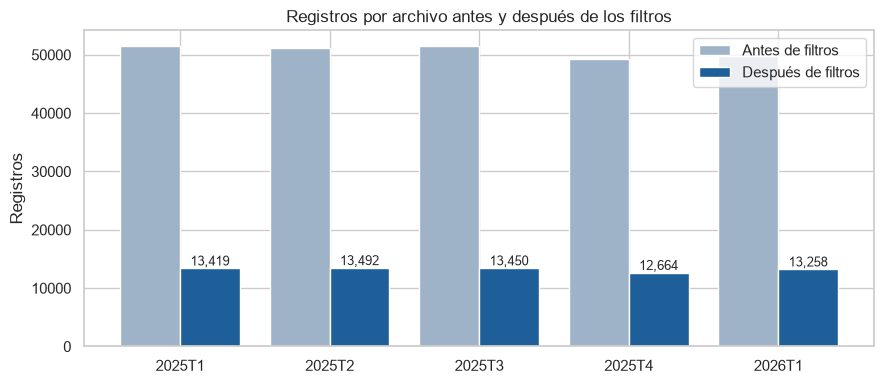

In [13]:
fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(antes_despues))
ax.bar(x - 0.2, antes_despues["antes_filtros"], 0.4, label="Antes de filtros", color="#9fb3c8")
ax.bar(x + 0.2, antes_despues["despues_filtros"], 0.4, label="Después de filtros", color="#1f5f99")
for i, r in antes_despues.iterrows():
    ax.text(i + 0.2, r["despues_filtros"], f'{r["despues_filtros"]:,}', ha="center", va="bottom", fontsize=9)
ax.set_xticks(x, antes_despues["periodo_archivo"])
ax.set_ylabel("Registros"); ax.set_title("Registros por archivo antes y después de los filtros")
ax.legend(); plt.tight_layout(); plt.show()

**¿Qué vemos?**

- En 2025 pasamos de **203,676 a 53,025** registros, más o menos 1 de cada 4. En 2026 quedan **13,258**.
- Solo los **3 primeros filtros** quitan gente: menores de 15, personas que no trabajan y quienes trabajan pero **no son asalariados** (por ejemplo, los que trabajan por cuenta propia).
- Los filtros 4 a 8 quitan **0 registros**. Esto quiere decir que los datos de los asalariados ya venían **limpios** (el INE ya los revisó). Igual los dejamos, para aplicarle la misma regla a 2026.
- Todos los trimestres conservan casi el mismo % (~26 %), así que ninguno pierde más datos que otro.

## 1.6 Revisar los códigos con el diccionario

Si un código no está en el diccionario, lo ponemos como `DESCONOCIDO`, **nunca como 0**. En educación, el **0 significa "Ninguno"**: es una respuesta válida, no un dato faltante.

In [14]:
def mapear(col_cod, dic):
    expr = F.lit("DESCONOCIDO")
    for k, v in sorted(dic.items(), reverse=True):
        expr = F.when(F.col(col_cod) == k, F.lit(f"{k}-{v}")).otherwise(expr)
    return F.when(F.col(col_cod).isNull(), F.lit("DESCONOCIDO")).otherwise(expr)

def preparar(df_m):
    return (df_m.filter(F.col("motivo_exclusion") == "0_CONSERVADO")
            .withColumn("antiguedad", F.col("antiguedad_anios") + F.col("antiguedad_meses") / 12)
            .withColumn("nivel_educativo", mapear("cod_nivel_educativo", DIC_NIVEL_EDUCATIVO))
            .withColumn("categoria_ocupacional", mapear("cod_categoria_ocupacional", DIC_CATEGORIA_OCUP))
            .withColumn("dominio", mapear("cod_dominio", DIC_DOMINIO))
            .select("archivo_origen", "periodo_archivo", "anio_archivo", "trimestre_calendario",
                    "ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
                    "salario_mensual", "edad", "antiguedad_anios", "antiguedad_meses", "antiguedad",
                    "horas_semanales", "nivel_educativo", "categoria_ocupacional", "dominio", "ocupado"))

df2025 = preparar(df2025_m).cache()
df2026 = preparar(df2026_m).cache()

for c in ["nivel_educativo", "categoria_ocupacional", "dominio"]:
    t = (df2025.groupBy(c).count().withColumnRenamed("count", "n_2025")
         .join(df2026.groupBy(c).count().withColumnRenamed("count", "n_2026"), c, "full")
         .orderBy(c).toPandas().fillna(0))
    display(t)

,nivel_educativo,n_2025,n_2026
0,0-NINGUNO,3995,1016
1,1-PREPRIMARIA,459,80
2,2-PRIMARIA,15822,3957
3,3-BÁSICO,8249,2164
4,4-DIVERSIFICADO,16851,4117
5,5-SUPERIOR,6818,1729
6,6-MAESTRÍA,771,183
7,7-DOCTORADO,60,12


,categoria_ocupacional,n_2025,n_2026
0,1-Empleado de gobierno,6575,1646
1,2-Empleado de empresa privada,28702,7503
2,3-Jornalero o peón,13842,3093
3,4-Servicio doméstico,3906,1016


,dominio,n_2025,n_2026
0,1-Urbano Metropolitano,22072,5632
1,2-Resto Urbano,20146,4846
2,3-Rural Nacional,10807,2780


**¿Qué vemos?** No salió **ningún `DESCONOCIDO`**, así que todos los códigos son válidos. Ojo con los grupos **muy pequeños**, como Doctorado (60 personas) o Preprimaria (459): con tan pocas personas, sus promedios pueden ser poco confiables.

## 1.7 ¿Hay registros repetidos?

Revisamos que cada combinación `periodo_archivo + NUM_HOGAR + NUM_PERSONA` aparezca **una sola vez**. Si alguna se repitiera, veríamos si es una copia exacta o si trae datos distintos. **No usamos `dropDuplicates()`**, porque eso escondería el problema.

In [15]:
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]
def revisar_unicidad(df, nombre):
    COLS_CONTENIDO = [c for c in df.columns if c not in CLAVE + ["archivo_origen"]]
    n = df.count()
    n_claves = df.select(*CLAVE).distinct().count()
    nulos_clave = df.filter(F.col("NUM_HOGAR").isNull() | F.col("NUM_PERSONA").isNull()).count()
    dup = df.groupBy(*CLAVE).agg(F.count("*").alias("n"),
                                 F.countDistinct(F.struct(*COLS_CONTENIDO)).alias("versiones")) \
            .filter(F.col("n") > 1)
    resumen = dup.agg(F.count("*").alias("claves_duplicadas"),
                      F.sum("n").alias("filas_involucradas"),
                      F.sum((F.col("versiones") == 1).cast("int")).alias("repeticiones_exactas"),
                      F.sum((F.col("versiones") > 1).cast("int")).alias("claves_en_conflicto")).first()
    return {"base": nombre, "registros": n, "claves_distintas": n_claves,
            "claves_con_nulos": nulos_clave, **{k: (v or 0) for k, v in resumen.asDict().items()}}, dup

res = []
dups = {}
for nombre, df in [("2025 completo", df2025_raw), ("2026 completo", df2026_raw),
                   ("2025 analítico", df2025), ("2026 analítico", df2026)]:
    r, d = revisar_unicidad(df, nombre)
    res.append(r); dups[nombre] = d
pd.DataFrame(res)

,base,registros,claves_distintas,claves_con_nulos,claves_duplicadas,filas_involucradas,repeticiones_exactas,claves_en_conflicto
0,2025 completo,203676,203676,0,0,0,0,0
1,2026 completo,49843,49843,0,0,0,0,0
2,2025 analítico,53025,53025,0,0,0,0,0
3,2026 analítico,13258,13258,0,0,0,0,0


In [16]:
# Si hubiera claves duplicadas, se muestran para investigarlas (no se eliminan)
for nombre, d in dups.items():
    if d.count() > 0:
        print(f"== {nombre}: claves duplicadas ==")
        claves = d.limit(10)
        base = df2025_raw.unionByName(df2026_raw)
        base.join(claves.select(*CLAVE), CLAVE).orderBy(*CLAVE).show(20, truncate=False)

**¿Qué vemos?** **No hay ningún repetido**: hay tantas claves distintas como registros. No hubo que borrar nada.

### La misma persona en varios trimestres

La encuesta **vuelve a visitar a los mismos hogares** en distintos trimestres, así que una persona puede aparecer varias veces. Eso **no es un error**.

In [17]:
apariciones = (df2025.groupBy("NUM_HOGAR", "NUM_PERSONA")
               .agg(F.countDistinct("periodo_archivo").alias("n_periodos"))
               .groupBy("n_periodos").count().orderBy("n_periodos").toPandas())
apariciones["%"] = (100 * apariciones["count"] / apariciones["count"].sum()).round(2)
print(f"Filas analíticas 2025: {df2025.count():,} | combinaciones hogar-persona distintas: {apariciones['count'].sum():,}")
apariciones

Filas analíticas 2025: 53,025 | combinaciones hogar-persona distintas: 26,709


,n_periodos,count,%
0,1,11303,42.32
1,2,7831,29.32
2,3,4240,15.87
3,4,3335,12.49


**¿Qué vemos?** Las 53,025 filas son en realidad unas **26,709 personas**, y más de la mitad (58 %) aparece en 2 o más trimestres. O sea, cada fila es **"una persona en un trimestre"**, no una persona distinta.

## 1.8 Guardar en Parquet

Guardamos 2025 y 2026 **por separado**. Las partes siguientes leen estos archivos.

In [18]:
RUTA_2025 = os.path.join(PARQ_DIR, "eneic_2025_preparado.parquet")
RUTA_2026 = os.path.join(PARQ_DIR, "eneic_2026_preparado.parquet")
df2025.write.mode("overwrite").parquet(RUTA_2025)
df2026.write.mode("overwrite").parquet(RUTA_2026)

df2025 = spark.read.parquet(RUTA_2025).cache()
df2026 = spark.read.parquet(RUTA_2026).cache()
print(f"2025 preparado: {df2025.count():,} filas -> {RUTA_2025}")
print(f"2026 preparado: {df2026.count():,} filas -> {RUTA_2026}")
df2025.printSchema()


[Stage 244:=============================================>         (33 + 7) / 40]



2025 preparado: 53,025 filas -> /Users/anggiequezada/Desktop/UVG/Data science/lab7-md/lab7-md/data/parquet/eneic_2025_preparado.parquet
2026 preparado: 13,258 filas -> /Users/anggiequezada/Desktop/UVG/Data science/lab7-md/lab7-md/data/parquet/eneic_2026_preparado.parquet
root
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- NUM_HOGAR: long (nullable = true)
 |-- NUM_PERSONA: integer (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_oc

## 1.9 Respuestas del Ejercicio 1

**¿Por qué IV-2025 no se puede apilar por posición de columnas?**
Porque tiene **302 columnas en vez de 270** y cada variable está en **otra posición**. Si pegáramos los archivos por posición, la edad de uno podría quedar debajo de otra pregunta del otro, y Spark no avisaría. Con `unionByName` se juntan por **nombre**, así que cada dato cae en su columna correcta.

**¿Qué diferencia hay entre "no corresponde" y "no registrado"?**
- **No corresponde:** la pregunta **no le tocaba** a esa persona. Por ejemplo, a un niño no se le pregunta su salario. Ese vacío es normal y no hay que rellenarlo.
- **No registrado:** la pregunta **sí le tocaba**, pero no hay respuesta (no quiso contestar, no sabía o hubo un error). Esto sí es información perdida.

En nuestros datos casi todo es del primer tipo, porque al quedarnos solo con los ocupados los faltantes bajan a 0 %.

**¿Por qué no borrar a una persona que aparece en dos trimestres?**
Porque **no es un duplicado**: es la misma persona en **momentos distintos**, y su salario, sus horas o su antigüedad pueden cambiar. Si la borráramos, perderíamos casi la mitad de los datos (de 53,025 a 26,709). Un duplicado de verdad sería la misma persona **dos veces en el mismo trimestre**, y eso no pasó.

**¿Por qué los registros filtrados no representan a todos los trabajadores del país?**
1. **Es una encuesta (muestra)**: cada persona encuestada "representa" a muchas más, y cuántas lo dice el `FACTOR`. Si solo contamos filas, no obtenemos el total del país.
2. **Solo dejamos a los asalariados**. Quedan fuera los que trabajan por su cuenta, los patronos, etc., que son un 40 % de los ocupados de esta muestra.
3. **Hay personas repetidas** en varios trimestres.



---
# PARTE 2 — Estadística descriptiva y relaciones entre variables (Ejercicios 2 y 3)

Trabajamos con la **población analítica de 2025** (53,025 registros), que leemos del Parquet de la Parte 1.

**Regla:** todas las estadísticas se calculan en Spark con **todos** los registros. A pandas solo pasamos **tablas ya resumidas** o una **muestra de 10,000** filas, y la muestra la usamos únicamente para dibujar.

In [19]:
df = spark.read.parquet(RUTA_2025).cache()
N_2025 = df.count()

# Muestra fija (misma semilla) SOLO para graficar
FRAC = min(1.0, 10000 / N_2025)
muestra = df.sample(fraction=FRAC, seed=42).limit(10000).toPandas()
print(f"Registros 2025: {N_2025:,} | muestra para gráficas: {len(muestra):,}")

Registros 2025: 53,025 | muestra para gráficas: 10,000


## 2.1 Estadísticas de las variables numéricas

Para cada variable calculamos: cantidad, media, mediana, desviación estándar, mínimo, máximo y los percentiles 25, 75 y 95. Los percentiles son **exactos** (función `percentile` de Spark).

In [20]:
VARS_NUM = {"salario_mensual": "Salario mensual (Q)", "edad": "Edad (años)",
            "antiguedad": "Antigüedad (años)", "horas_semanales": "Horas habituales / semana"}

def resumen(df, c):
    r = df.agg(F.count(c).alias("n"), F.mean(c).alias("media"),
               F.stddev(c).alias("desv_std"), F.min(c).alias("min"), F.max(c).alias("max"),
               F.expr(f"percentile({c}, array(0.25, 0.5, 0.75, 0.95))").alias("p"),
               F.skewness(c).alias("asimetria")).first()
    p25, p50, p75, p95 = r["p"]
    return {"variable": VARS_NUM[c], "n": r["n"], "media": r["media"], "mediana": p50,
            "desv_std": r["desv_std"], "min": r["min"], "p25": p25, "p75": p75, "p95": p95,
            "max": r["max"], "asimetria": r["asimetria"]}

desc = pd.DataFrame([resumen(df, c) for c in VARS_NUM]).set_index("variable")
desc.round(2)

,n,media,mediana,desv_std,min,p25,p75,p95,max,asimetria
variable,,,,,,,,,,
Salario mensual (Q),53025,3421.68,3000.0,2902.11,1.0,1800.0,4000.0,8000.0,99000.0,6.00
Edad (años),53025,35.19,33.0,13.52,15.0,24.0,44.0,61.0,89.0,0.74
Antigüedad (años),53025,5.56,2.0,7.83,0.0,0.5,7.0,22.0,70.0,2.40
Horas habituales / semana,53025,46.31,45.0,18.63,1.0,40.0,55.0,80.0,126.0,0.59


**¿Qué vemos?**

- **Salario:** la media (Q3,422) es mayor que la mediana (Q3,000), y el máximo (Q99,000) está lejísimos del P95 (Q8,000). Esto pasa porque **unos pocos salarios muy altos jalan la media hacia arriba**.
- **Edad:** la mitad tiene 33 años o menos, y el rango va de 15 a 89. Es una población bastante **joven**.
- **Antigüedad:** la mediana es de solo **2 años**, pero la media es de 5.6. Esto pasa porque la mayoría lleva poco tiempo en su trabajo y unos pocos llevan décadas.
- **Horas:** la mediana es de 45 horas por semana, un poco más de una jornada de 40. El 5 % trabaja 80 horas o más.



## 2.2 ¿Cómo se reparten los registros entre categorías, niveles educativos y dominios?

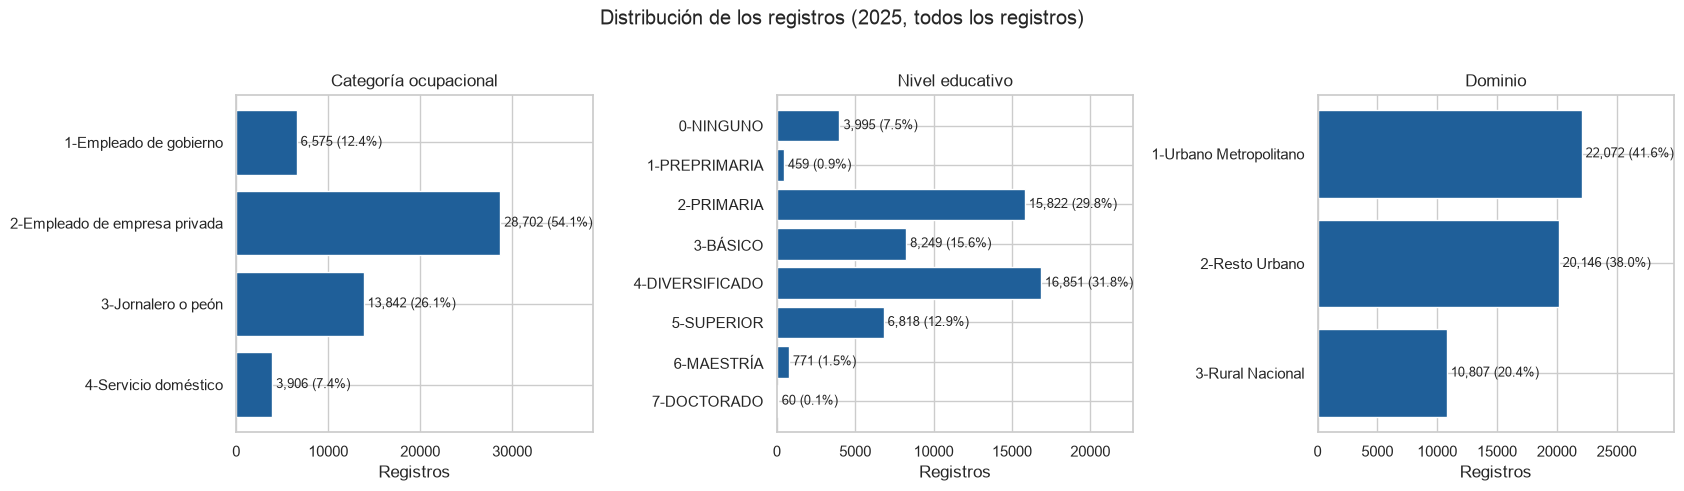

In [21]:
def conteo(c):
    t = df.groupBy(c).count().orderBy(c).toPandas()
    t["%"] = 100 * t["count"] / t["count"].sum()
    return t

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, c, titulo in zip(axes, ["categoria_ocupacional", "nivel_educativo", "dominio"],
                         ["Categoría ocupacional", "Nivel educativo", "Dominio"]):
    t = conteo(c)
    ax.barh(t[c], t["count"], color="#1f5f99")
    for i, (n, pct) in enumerate(zip(t["count"], t["%"])):
        ax.text(n, i, f" {n:,} ({pct:.1f}%)", va="center", fontsize=9)
    ax.invert_yaxis(); ax.set_title(titulo); ax.set_xlabel("Registros")
    ax.set_xlim(0, t["count"].max() * 1.35)
plt.suptitle("Distribución de los registros (2025, todos los registros)", y=1.02)
plt.tight_layout(); plt.show()

**¿Qué vemos?**

- **Categoría:** más de la mitad son **empleados de empresa privada** (54 %). Siguen los **jornaleros o peones** (26 %), luego **gobierno** (12 %) y **servicio doméstico** (7 %).
- **Educación:** los grupos más grandes son **Diversificado** (32 %) y **Primaria** (30 %). Maestría y Doctorado juntos no llegan al 2 %, así que son grupos **muy pequeños**.
- **Dominio:** hay más registros **urbanos** (Metropolitano 42 % y Resto Urbano 38 %) que **rurales** (20 %). Esto pasa en parte porque en el área rural hay menos empleo asalariado; allí muchas personas trabajan por su cuenta.

## 2.3 ¿El salario es simétrico o asimétrico? ¿Qué pasa con la media y la mediana?

Dibujamos el histograma en **escala normal** y en **escala logarítmica** (esta última solo para verlo mejor). Las líneas de media y mediana se calcularon con **todos** los registros.

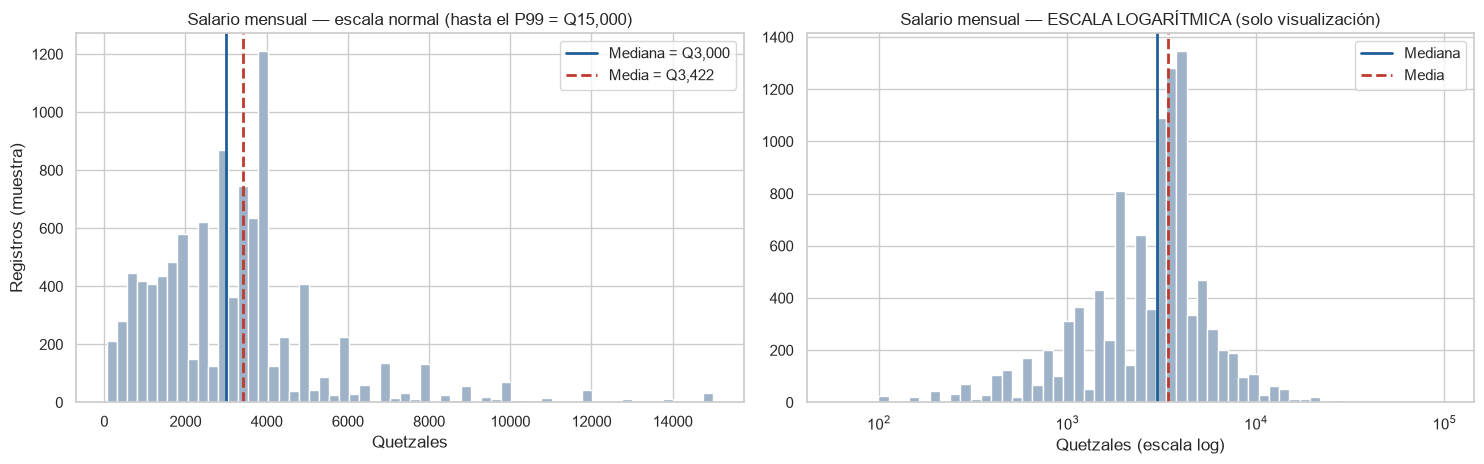

Media: Q3,421.68 | Mediana: Q3,000.00 | Diferencia: Q421.68 (14.1% más alta la media)
Asimetría (skewness): 6.00


In [22]:
media_sal = desc.loc["Salario mensual (Q)", "media"]
mediana_sal = desc.loc["Salario mensual (Q)", "mediana"]
p95_sal = desc.loc["Salario mensual (Q)", "p95"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
ax = axes[0]
p99_sal = df.agg(F.expr("percentile(salario_mensual, 0.99)")).first()[0]
ax.hist(muestra.loc[muestra["salario_mensual"] <= p99_sal, "salario_mensual"], bins=60, color="#9fb3c8", edgecolor="white")
ax.axvline(mediana_sal, color="#1f5f99", lw=2, label=f"Mediana = Q{mediana_sal:,.0f}")
ax.axvline(media_sal, color="#c0392b", lw=2, ls="--", label=f"Media = Q{media_sal:,.0f}")
ax.set_title(f"Salario mensual — escala normal (hasta el P99 = Q{p99_sal:,.0f})"); ax.set_xlabel("Quetzales"); ax.set_ylabel("Registros (muestra)")
ax.legend()

ax = axes[1]
bins_log = np.logspace(np.log10(muestra["salario_mensual"].min()), np.log10(muestra["salario_mensual"].max()), 60)
ax.hist(muestra["salario_mensual"], bins=bins_log, color="#9fb3c8", edgecolor="white")
ax.axvline(mediana_sal, color="#1f5f99", lw=2, label="Mediana")
ax.axvline(media_sal, color="#c0392b", lw=2, ls="--", label="Media")
ax.set_xscale("log"); ax.set_title("Salario mensual — ESCALA LOGARÍTMICA (solo visualización)")
ax.set_xlabel("Quetzales (escala log)"); ax.legend()
plt.tight_layout(); plt.show()

print(f"Media: Q{media_sal:,.2f} | Mediana: Q{mediana_sal:,.2f} | Diferencia: Q{media_sal - mediana_sal:,.2f} "
      f"({100 * (media_sal / mediana_sal - 1):.1f}% más alta la media)")
print(f"Asimetría (skewness): {desc.loc['Salario mensual (Q)', 'asimetria']:.2f}")

**¿Qué vemos?**

- El salario es **muy asimétrico hacia la derecha**: casi todos están amontonados entre Q1,000 y Q5,000, y hay una "cola" larga de salarios altos. En escala log se ve mucho más ordenado, casi como una campana.
- La **media (Q3,422) es un 14 % más alta que la mediana (Q3,000)**. Esto pasa porque los pocos salarios muy altos suben el promedio, pero no mueven la mediana.
- Por eso la **mediana describe mejor** al trabajador "típico".
- Se ven "picos" en números redondos (Q2,000, Q3,000, Q4,000…). Esto pasa porque la gente **redondea** su salario al responder la encuesta.

¿Qué tan grandes son los salarios más altos? Vemos la parte alta de la distribución con todos los registros:

In [23]:
cortes = [0.5, 0.75, 0.9, 0.95, 0.99, 0.999]
pcts = df.agg(F.expr(f"percentile(salario_mensual, array({','.join(map(str, cortes))}))").alias("p")).first()["p"]
cola = pd.DataFrame({"percentil": [f"P{c*100:g}" for c in cortes], "salario_Q": pcts})
n_sobre_p95 = df.filter(F.col("salario_mensual") > p95_sal).count()
suma_total = df.agg(F.sum("salario_mensual")).first()[0]
suma_top5 = df.filter(F.col("salario_mensual") > p95_sal).agg(F.sum("salario_mensual")).first()[0]
n_bajo_500 = df.filter(F.col("salario_mensual") < 500).count()
print(f"Registros con salario menor a Q500: {n_bajo_500:,} ({100*n_bajo_500/N_2025:.1f}%)")
print(f"Registros arriba del P95: {n_sobre_p95:,} | concentran el {100*suma_top5/suma_total:.1f}% de la suma de salarios")
cola.round(0)

Registros con salario menor a Q500: 1,946 (3.7%)
Registros arriba del P95: 2,341 | concentran el 16.5% de la suma de salarios


,percentil,salario_Q
0,P50,3000.0
1,P75,4000.0
2,P90,6000.0
3,P95,8000.0
4,P99,15000.0
5,P99.9,30000.0


**¿Qué vemos?**

- De la mediana (Q3,000) al P99 el salario se multiplica por 5 (Q15,000), y al P99.9 por 10 (Q30,000).
- El **5 % que más gana** (2,341 registros) se lleva el **16.5 %** de todo el dinero en salarios.
- También hay salarios **muy bajos**: 1,946 registros (3.7 %) ganan menos de Q500 al mes, y el mínimo es Q1. Podría tratarse de trabajos de pocas horas o de errores de captura. **No los quitamos**, como pide el lab, pero hay que tenerlos en cuenta al modelar.

## 2.4 Salario mediano por nivel educativo y por categoría ocupacional

Usamos la **mediana** (y no la media) porque los salarios muy altos la afectan menos. También mostramos cuántos registros tiene cada grupo.

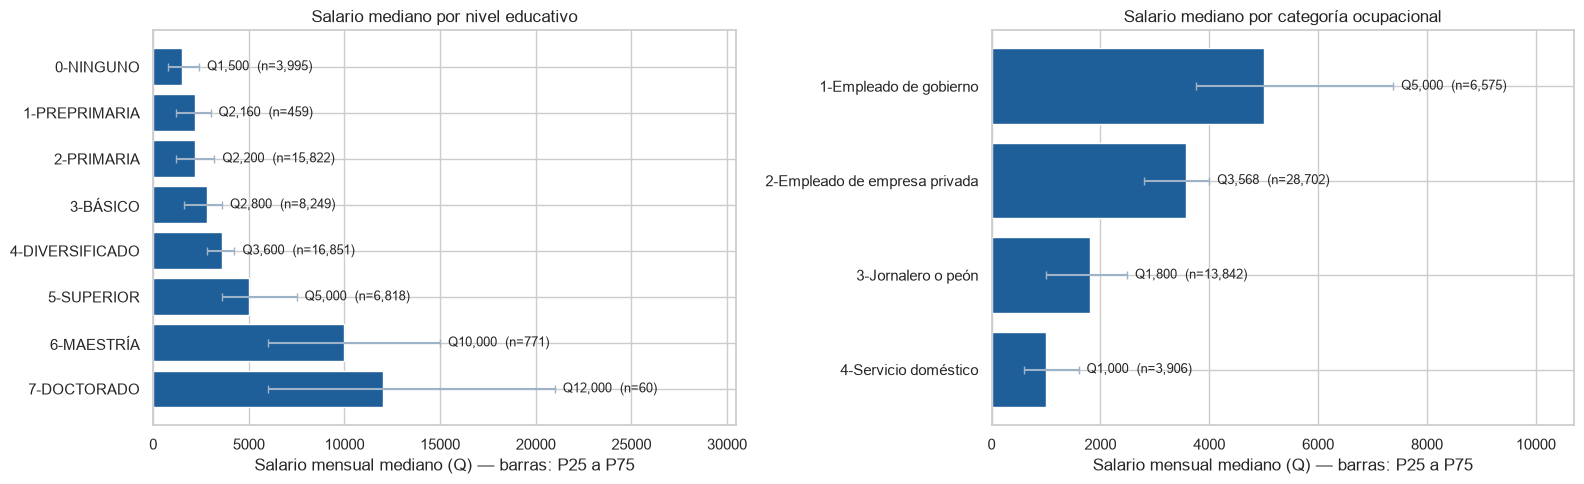

,nivel_educativo,n,mediana,media,p25,p75
0,0-NINGUNO,3995,1500.0,1767.0,800.0,2400.0
1,1-PREPRIMARIA,459,2160.0,2242.0,1200.0,3000.0
2,2-PRIMARIA,15822,2200.0,2308.0,1200.0,3200.0
3,3-BÁSICO,8249,2800.0,2730.0,1600.0,3600.0
4,4-DIVERSIFICADO,16851,3600.0,3796.0,2800.0,4250.0
5,5-SUPERIOR,6818,5000.0,5965.0,3600.0,7500.0
6,6-MAESTRÍA,771,10000.0,11409.0,6000.0,15000.0
7,7-DOCTORADO,60,12000.0,14452.0,6000.0,21000.0


,categoria_ocupacional,n,mediana,media,p25,p75
0,1-Empleado de gobierno,6575,5000.0,5972.0,3750.0,7380.0
1,2-Empleado de empresa privada,28702,3568.0,3875.0,2800.0,4000.0
2,3-Jornalero o peón,13842,1800.0,1879.0,1000.0,2490.0
3,4-Servicio doméstico,3906,1000.0,1266.0,600.0,1600.0


In [24]:
def mediana_por(c):
    return (df.groupBy(c)
              .agg(F.count("*").alias("n"),
                   F.expr("percentile(salario_mensual, 0.5)").alias("mediana"),
                   F.mean("salario_mensual").alias("media"),
                   F.expr("percentile(salario_mensual, 0.25)").alias("p25"),
                   F.expr("percentile(salario_mensual, 0.75)").alias("p75"))
              .orderBy(c).toPandas())

med_edu = mediana_por("nivel_educativo")
med_cat = mediana_por("categoria_ocupacional")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, t, c, titulo in [(axes[0], med_edu, "nivel_educativo", "Nivel educativo"),
                         (axes[1], med_cat, "categoria_ocupacional", "Categoría ocupacional")]:
    ax.barh(t[c], t["mediana"], color="#1f5f99",
            xerr=[t["mediana"] - t["p25"], t["p75"] - t["mediana"]], ecolor="#9fb3c8", capsize=3)
    for i, r in t.iterrows():
        ax.text(r["p75"], i, f"  Q{r['mediana']:,.0f}  (n={r['n']:,})", va="center", fontsize=9)
    ax.invert_yaxis(); ax.set_xlabel("Salario mensual mediano (Q) — barras: P25 a P75")
    ax.set_title(f"Salario mediano por {titulo.lower()}")
    ax.set_xlim(0, t["p75"].max() * 1.45)
plt.tight_layout(); plt.show()
display(med_edu.round(0)); display(med_cat.round(0))

**¿Qué vemos?**

- **Educación:** a más estudio, **más salario**. De Ninguno (Q1,500) a Primaria (Q2,200), Diversificado (Q3,600), Superior (Q5,000) y Maestría (Q10,000). Una persona con título universitario gana **más del triple** que una sin estudios.
- El salto más grande está **después de Superior**: con Maestría la mediana se duplica.
- Doctorado tiene la mediana más alta (Q12,000), pero **solo 60 registros** y una dispersión enorme (de Q6,000 a Q21,000). Es un resultado **poco estable**.
- **Categoría:** **gobierno** paga la mediana más alta (Q5,000), seguido de **empresa privada** (Q3,568). **Jornaleros** (Q1,800) y **servicio doméstico** (Q1,000) ganan mucho menos. Esto pasa porque son trabajos con menos requisitos de estudio, y muchas veces de medio tiempo o temporales.

Para ver la **dispersión completa** dentro de cada grupo, usamos un boxplot con la muestra (escala log solo para verlo mejor):

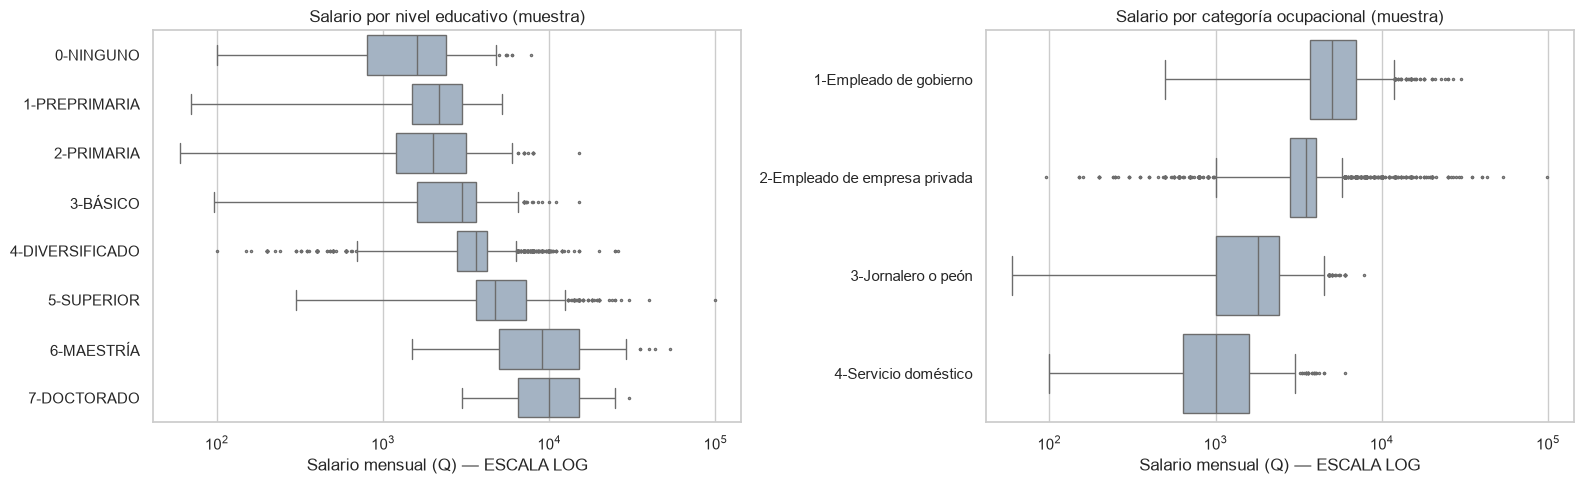

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
orden_edu = sorted(muestra["nivel_educativo"].unique())
orden_cat = sorted(muestra["categoria_ocupacional"].unique())
sns.boxplot(data=muestra, y="nivel_educativo", x="salario_mensual", order=orden_edu, ax=axes[0],
            color="#9fb3c8", fliersize=1.5)
sns.boxplot(data=muestra, y="categoria_ocupacional", x="salario_mensual", order=orden_cat, ax=axes[1],
            color="#9fb3c8", fliersize=1.5)
for ax in axes:
    ax.set_xscale("log"); ax.set_xlabel("Salario mensual (Q) — ESCALA LOG"); ax.set_ylabel("")
axes[0].set_title("Salario por nivel educativo (muestra)")
axes[1].set_title("Salario por categoría ocupacional (muestra)")
plt.tight_layout(); plt.show()

**¿Qué vemos?** Las cajas **se traslapan bastante**, sobre todo en los niveles bajos. Hay personas con Primaria que ganan más que otras con Diversificado. O sea, la educación **ayuda a explicar** el salario, pero **no lo determina sola**.

## 2.5 ¿Cómo cambian el tamaño de la muestra y el salario mediano entre trimestres?

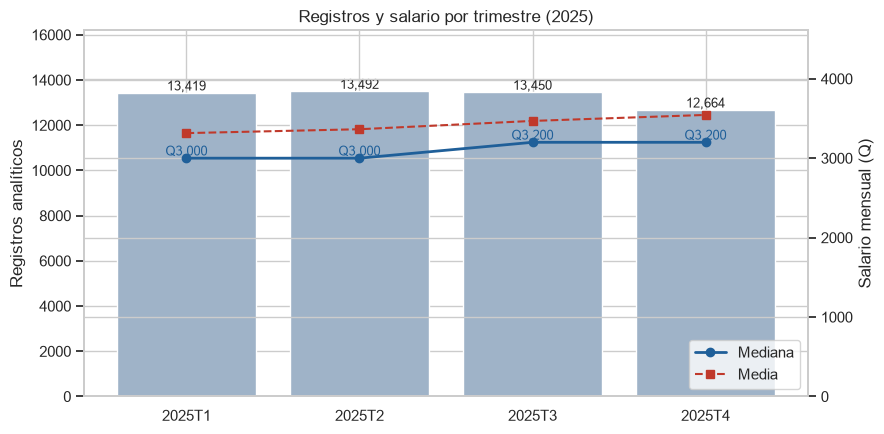

,periodo_archivo,n,mediana,media
0,2025T1,13419,3000.0,3316.0
1,2025T2,13492,3000.0,3365.0
2,2025T3,13450,3200.0,3469.0
3,2025T4,12664,3200.0,3545.0


In [26]:
por_trim = (df.groupBy("periodo_archivo")
              .agg(F.count("*").alias("n"),
                   F.expr("percentile(salario_mensual, 0.5)").alias("mediana"),
                   F.mean("salario_mensual").alias("media"))
              .orderBy("periodo_archivo").toPandas())

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.bar(por_trim["periodo_archivo"], por_trim["n"], color="#9fb3c8", label="Registros")
for i, n in enumerate(por_trim["n"]):
    ax1.text(i, n, f"{n:,}", ha="center", va="bottom", fontsize=9)
ax1.set_ylabel("Registros analíticos"); ax1.set_ylim(0, por_trim["n"].max() * 1.2)
ax2 = ax1.twinx()
ax2.plot(por_trim["periodo_archivo"], por_trim["mediana"], "o-", color="#1f5f99", lw=2, label="Mediana")
ax2.plot(por_trim["periodo_archivo"], por_trim["media"], "s--", color="#c0392b", lw=1.5, label="Media")
for i, m in enumerate(por_trim["mediana"]):
    ax2.text(i, m, f"Q{m:,.0f}", ha="center", va="bottom", fontsize=9, color="#1f5f99")
ax2.set_ylabel("Salario mensual (Q)"); ax2.set_ylim(0, por_trim["media"].max() * 1.3)
ax2.legend(loc="lower right"); ax1.set_title("Registros y salario por trimestre (2025)")
plt.tight_layout(); plt.show()
por_trim.round(0)

**¿Qué vemos?**

- El **tamaño de la muestra** es casi igual en los tres primeros trimestres (~13,450) y **baja un poco en T4** (12,664). Esto pasa porque el archivo de IV-2025 ya traía menos registros desde el origen (49,338).
- El **salario mediano sube un poco**: Q3,000 en T1 y T2, y Q3,200 en T3 y T4. La media también crece poco a poco (de Q3,316 a Q3,545).
- Los cambios son **pequeños**, así que los cuatro trimestres son **parecidos**. Esto es bueno, porque entrenar con T1–T3 y validar con T4 no debería causar sorpresas grandes.

---
## 3. Relaciones entre variables numéricas (Ejercicio 3)

Calculamos la **correlación de Pearson** con `VectorAssembler` + `Correlation.corr()`, usando **todos** los registros de 2025.

Recordatorio: la correlación va de **-1 a 1**. Si está cerca de 0, casi no hay relación **lineal** entre las dos variables. Si está cerca de 1 (o de -1), cuando una sube la otra también sube (o baja).

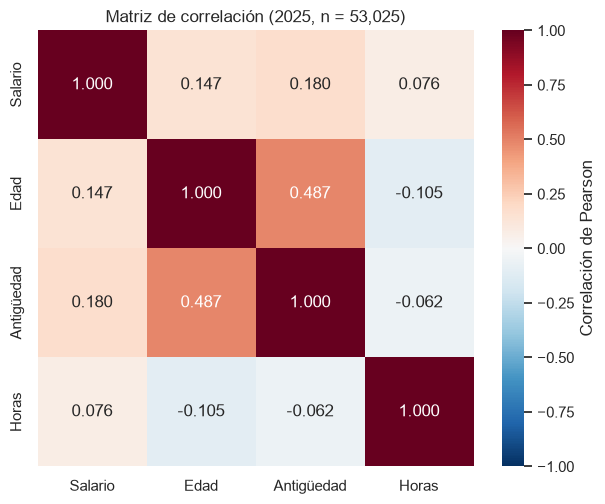

,Salario,Edad,Antigüedad,Horas
Salario,1.000,0.147,0.180,0.076
Edad,0.147,1.000,0.487,-0.105
Antigüedad,0.180,0.487,1.000,-0.062
Horas,0.076,-0.105,-0.062,1.000


In [27]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

COLS_CORR = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]
ETIQ_CORR = ["Salario", "Edad", "Antigüedad", "Horas"]

vec = VectorAssembler(inputCols=COLS_CORR, outputCol="features").transform(df).select("features")
matriz = Correlation.corr(vec, "features", method="pearson").head()[0].toArray()
corr = pd.DataFrame(matriz, index=ETIQ_CORR, columns=ETIQ_CORR)

fig, ax = plt.subplots(figsize=(6.5, 5.2))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, ax=ax,
            cbar_kws={"label": "Correlación de Pearson"})
ax.set_title(f"Matriz de correlación (2025, n = {N_2025:,})")
plt.tight_layout(); plt.show()
corr.round(3)

Para verlo con puntos, dibujamos la muestra: edad contra antigüedad, y salario contra cada variable.

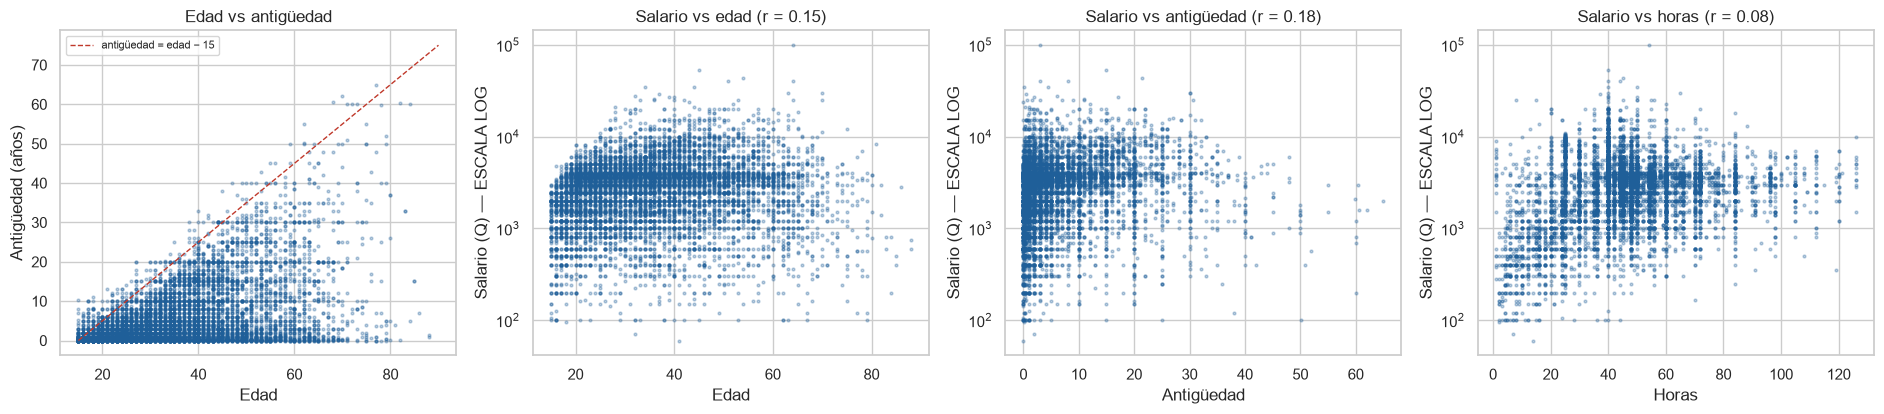

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(19, 4.3))
axes[0].scatter(muestra["edad"], muestra["antiguedad"], s=4, alpha=0.3, color="#1f5f99")
axes[0].plot([15, 90], [0, 75], color="#c0392b", lw=1, ls="--", label="antigüedad = edad − 15")
axes[0].set_xlabel("Edad"); axes[0].set_ylabel("Antigüedad (años)"); axes[0].set_title("Edad vs antigüedad")
axes[0].legend(fontsize=8)
for ax, c, et in zip(axes[1:], ["edad", "antiguedad", "horas_semanales"], ["Edad", "Antigüedad", "Horas"]):
    ax.scatter(muestra[c], muestra["salario_mensual"], s=4, alpha=0.3, color="#1f5f99")
    ax.set_yscale("log"); ax.set_xlabel(et); ax.set_ylabel("Salario (Q) — ESCALA LOG")
    ax.set_title(f"Salario vs {et.lower()} (r = {corr.loc['Salario', et]:.2f})")
plt.tight_layout(); plt.show()

**¿Qué vemos?**

- **Todas las correlaciones con el salario son débiles**: antigüedad 0.18, edad 0.15 y horas 0.08. Esto quiere decir que **ninguna de estas variables sola predice bien el salario**. En las gráficas se ve una "nube" de puntos sin una línea clara.
- La que más se relaciona es la **antigüedad (0.18)**: a más años en el trabajo, un poco más de salario.
- Las **horas casi no importan (0.08)**. Esto pasa porque trabajar más horas no significa ganar más. Por ejemplo, un jornalero puede trabajar 60 horas y ganar poco, y un empleado de gobierno trabajar 40 y ganar más. Lo que sí se ve es que quienes trabajan **menos de ~20 horas** suelen ganar menos, y eso explica varios de los salarios muy bajos.
- Además, la correlación de Pearson solo mide relaciones **en línea recta**, y el salario es muy asimétrico, así que los valores extremos la afectan.

**¿Existe relación entre edad y antigüedad?**
Sí, es la **relación más fuerte de la matriz (0.49, moderada)**. Tiene sentido, porque para llevar muchos años en un trabajo necesitás tener cierta edad. En la gráfica, casi todos los puntos quedan **debajo de la línea roja** (antigüedad = edad − 15). Los pocos que quedan arriba son personas que **empezaron a trabajar antes de los 15 años**. Pero no es perfecta, porque hay muchas personas mayores con poca antigüedad (cambiaron de trabajo).

 **Para los modelos:** como las variables numéricas se relacionan poco con el salario, lo más probable es que las **categóricas (educación y categoría ocupacional)** aporten más a la predicción, como vimos en la sección 2.4.


---
# PARTE 3 — Segmentación de perfiles con KMeans (Ejercicio 4)

Queremos agrupar a los trabajadores en **perfiles parecidos**, según su edad, antigüedad, horas y salario.



In [29]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

# log del salario SOLO para el clustering (el salario original en Q se mantiene intacto para los modelos)
df_k = df.withColumn("log_salario", F.log10("salario_mensual")).cache()

CONJUNTOS = {
    "A: sin salario":  ["edad", "antiguedad", "horas_semanales"],
    "B: con salario":  ["edad", "antiguedad", "horas_semanales", "log_salario"],
}
KS = [2, 3, 4, 5]

## 4.1 ¿Cuántos clusters (K)?

Usamos dos medidas:
- **Silhouette** (de -1 a 1): qué tan bien separado está cada grupo de los demás. **Más alto es mejor.**
- **WSSSE** (codo): qué tan "apretados" quedan los puntos dentro de cada grupo. Siempre baja al subir K, así que buscamos el punto donde **deja de bajar tanto**.

También revisamos el tamaño del cluster más chico, porque un grupo diminuto no sirve como perfil.

In [30]:
def ajustar(cols, k, datos=df_k):
    pipe = Pipeline(stages=[
        VectorAssembler(inputCols=cols, outputCol="vec"),
        StandardScaler(inputCol="vec", outputCol="features", withMean=True, withStd=True),
        KMeans(featuresCol="features", predictionCol="cluster", k=k, seed=42, maxIter=50),
    ])
    return pipe.fit(datos)

evaluador = ClusteringEvaluator(featuresCol="features", predictionCol="cluster",
                                metricName="silhouette", distanceMeasure="squaredEuclidean")
resultados, modelos = [], {}
for nombre, cols in CONJUNTOS.items():
    for k in KS:
        m = ajustar(cols, k)
        pred = m.transform(df_k)
        tam = [r["count"] for r in pred.groupBy("cluster").count().collect()]
        resultados.append({"conjunto": nombre, "k": k,
                           "silhouette": evaluador.evaluate(pred),
                           "WSSSE": m.stages[-1].summary.trainingCost,
                           "cluster_mas_chico_%": 100 * min(tam) / sum(tam)})
        modelos[(nombre, k)] = m
res_k = pd.DataFrame(resultados)
res_k.round(3)

,conjunto,k,silhouette,WSSSE,cluster_mas_chico_%
0,A: sin salario,2,0.554,106717.388,27.542
1,A: sin salario,3,0.419,84311.615,14.363
2,A: sin salario,4,0.476,64438.280,12.947
3,A: sin salario,5,0.484,54990.353,11.653
4,B: con salario,2,0.470,159174.106,28.268
5,B: con salario,3,0.475,125145.262,17.709
6,B: con salario,4,0.372,107227.465,11.540
7,B: con salario,5,0.387,91791.183,11.300


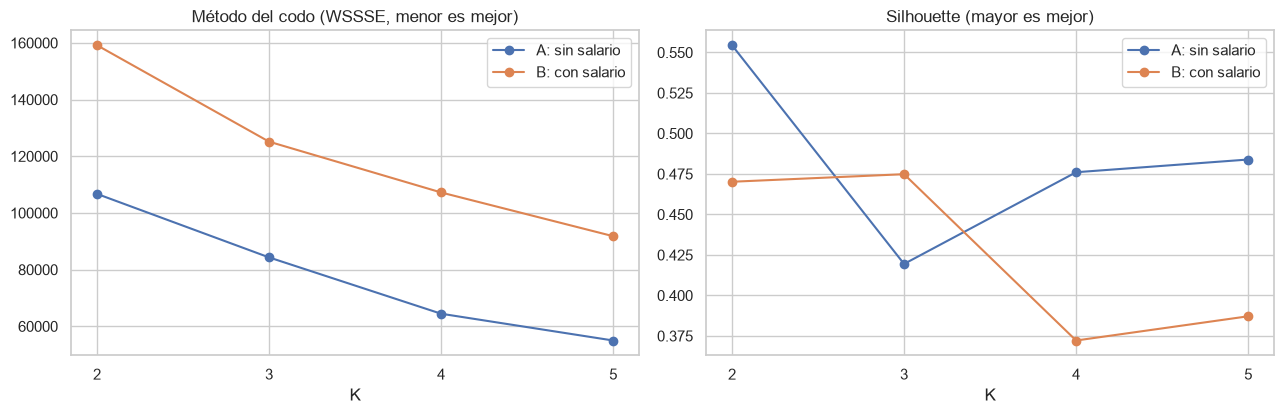

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3))
for nombre, t in res_k.groupby("conjunto"):
    axes[0].plot(t["k"], t["WSSSE"], "o-", label=nombre)
    axes[1].plot(t["k"], t["silhouette"], "o-", label=nombre)
axes[0].set_title("Método del codo (WSSSE, menor es mejor)"); axes[0].set_xlabel("K")
axes[1].set_title("Silhouette (mayor es mejor)"); axes[1].set_xlabel("K")
for ax in axes: ax.set_xticks(KS); ax.legend()
plt.tight_layout(); plt.show()

**¿Qué vemos?**

- **Sin salario (A):** el mejor silhouette es **K=2 (0.554)**, pero solo separa a los **jóvenes de los mayores**. Es un resultado obvio que no dice mucho. Con K=3 el silhouette baja bastante (0.419).
- **Con salario (B):** el mejor es **K=3 (0.475)**, un poco mejor que K=2 (0.470). Con K=4 y K=5 baja claramente (0.37 a 0.39).
- En el codo, la caída de WSSSE es fuerte de K=2 a K=3 y después se hace más pareja.

**Decisión: versión B (con salario) y K = 3.** Por tres razones:
1. Tiene el **mejor silhouette** de la versión B.
2. Ningún grupo es muy chico: el menor tiene el 17.7 %.
3. Es la opción que **mejor se puede interpretar**: aparece un grupo de trabajo de **pocas horas y salario bajo** que sin el salario no se ve.

**¿Vale la pena incluir el salario?** Sí. Sin salario, los grupos solo se diferencian por edad. Con el salario aparece el perfil de **trabajos precarios**, que es justo lo que interesa para programas de capacitación. Eso sí, la silhouette de A con K=2 es un poco más alta, así que el salario **no hace los grupos más "separados"**, pero sí más **útiles**.

## 4.2 Perfil de cada cluster

In [32]:
CONJ_FINAL, K_FINAL = "B: con salario", 3
modelo_km = modelos[(CONJ_FINAL, K_FINAL)]
seg = modelo_km.transform(df_k).drop("vec", "features").cache()

perfil = (seg.groupBy("cluster")
          .agg(F.count("*").alias("n"),
               F.round(F.mean("edad"), 1).alias("edad_media"),
               F.round(F.mean("antiguedad"), 1).alias("antig_media"),
               F.expr("percentile(antiguedad, 0.5)").alias("antig_mediana"),
               F.round(F.mean("horas_semanales"), 1).alias("horas_media"),
               F.expr("percentile(salario_mensual, 0.5)").alias("salario_mediano"),
               F.round(F.mean("salario_mensual"), 0).alias("salario_medio"))
          .orderBy("cluster").toPandas())
perfil["%"] = (100 * perfil["n"] / perfil["n"].sum()).round(1)
perfil

,cluster,n,edad_media,antig_media,antig_mediana,horas_media,salario_mediano,salario_medio,%
0,0,9390,35.3,2.9,1.000000,26.3,960.0,1034.0,17.7
1,1,10406,51.0,17.2,16.000000,43.6,3800.0,4942.0,19.6
2,2,33229,30.2,2.7,1.666667,52.8,3400.0,3620.0,62.7


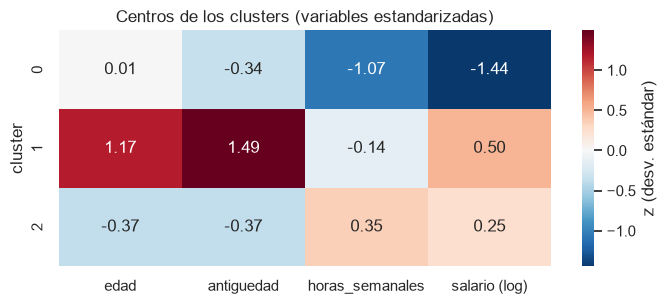

In [33]:
# Centros en unidades estandarizadas (z): cuántas desviaciones estándar está cada grupo sobre/bajo el promedio
centros = pd.DataFrame(modelo_km.stages[-1].clusterCenters(), columns=CONJUNTOS[CONJ_FINAL])
centros.index.name = "cluster"
fig, ax = plt.subplots(figsize=(7, 3.2))
sns.heatmap(centros.rename(columns={"log_salario": "salario (log)"}), annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, ax=ax, cbar_kws={"label": "z (desv. estándar)"})
ax.set_title("Centros de los clusters (variables estandarizadas)")
plt.tight_layout(); plt.show()

**¿Cómo leer el mapa de calor?** Cada número dice cuántas desviaciones estándar está el grupo **por encima (rojo) o por debajo (azul)** del promedio. Por ejemplo, el cluster 0 tiene -1.07 en horas: trabaja mucho **menos** horas que el promedio.

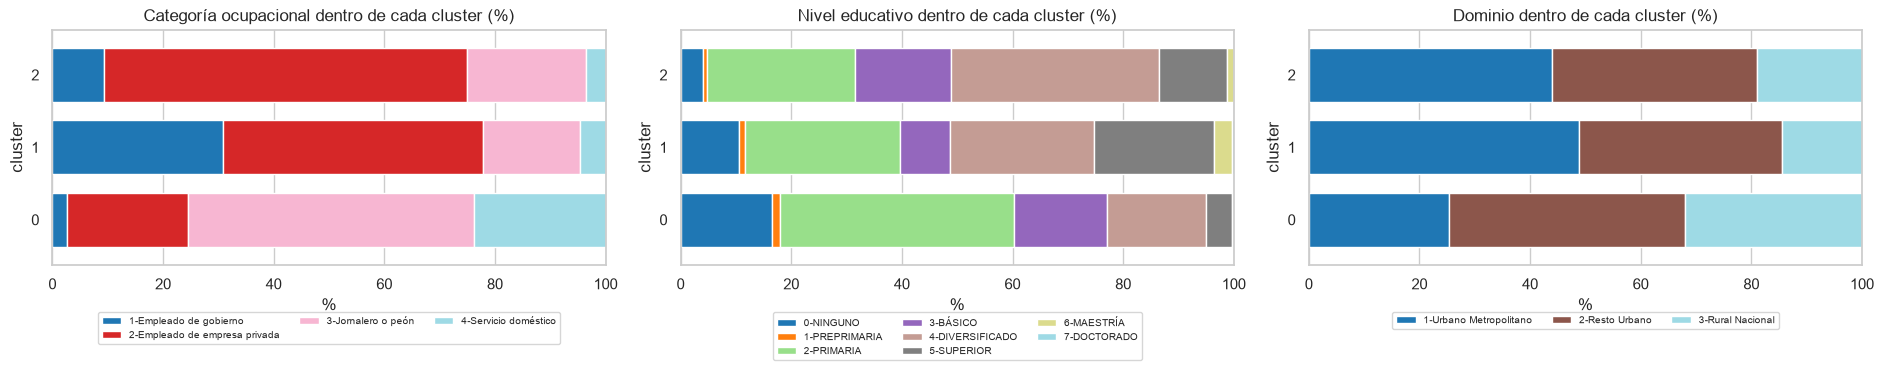

categoria_ocupacional,1-Empleado de gobierno,2-Empleado de empresa privada,3-Jornalero o peón,4-Servicio doméstico
cluster,,,,
0,2.7,21.9,51.7,23.7
1,30.8,47.0,17.6,4.6
2,9.4,65.5,21.5,3.6


nivel_educativo,0-NINGUNO,1-PREPRIMARIA,2-PRIMARIA,3-BÁSICO,4-DIVERSIFICADO,5-SUPERIOR,6-MAESTRÍA,7-DOCTORADO
cluster,,,,,,,,
0,16.5,1.5,42.3,16.7,17.9,4.8,0.2,0.0
1,10.6,1.0,28.0,9.1,26.1,21.6,3.2,0.5
2,4.0,0.7,26.9,17.3,37.5,12.4,1.3,0.0


dominio,1-Urbano Metropolitano,2-Resto Urbano,3-Rural Nacional
cluster,,,
0,25.4,42.6,32.0
1,48.8,36.7,14.5
2,44.0,37.1,19.0


In [34]:
def mezcla(c):
    t = seg.groupBy("cluster", c).count().toPandas()
    t = t.pivot(index="cluster", columns=c, values="count").fillna(0)
    return (100 * t.div(t.sum(axis=1), axis=0)).round(1)

fig, axes = plt.subplots(1, 3, figsize=(19, 4))
for ax, c, titulo in zip(axes, ["categoria_ocupacional", "nivel_educativo", "dominio"],
                         ["Categoría ocupacional", "Nivel educativo", "Dominio"]):
    t = mezcla(c)
    t.plot(kind="barh", stacked=True, ax=ax, colormap="tab20", width=0.75, legend=False)
    ax.set_title(f"{titulo} dentro de cada cluster (%)"); ax.set_xlabel("%"); ax.set_xlim(0, 100)
    ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3)
plt.tight_layout(); plt.show()
for c in ["categoria_ocupacional", "nivel_educativo", "dominio"]:
    display(mezcla(c))

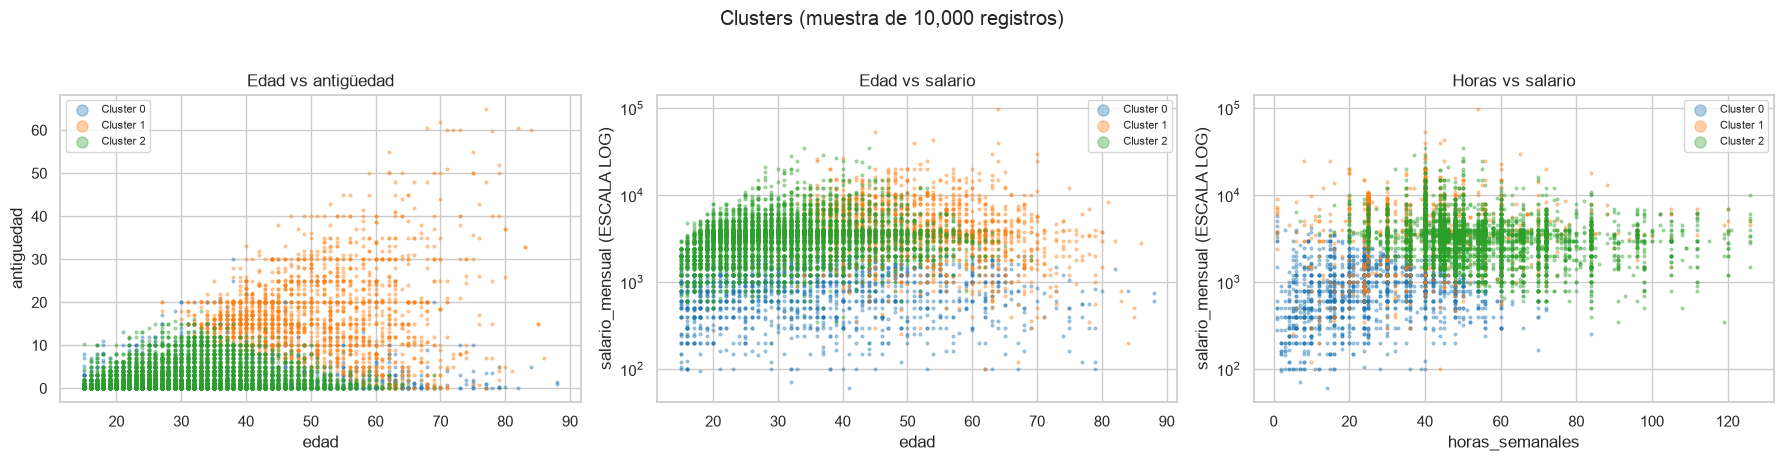

In [35]:
m_seg = seg.sample(fraction=min(1.0, 10000 / seg.count()), seed=42).limit(10000).toPandas()
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
paleta = sns.color_palette("tab10", K_FINAL)
for ax, (x, y, ylog) in zip(axes, [("edad", "antiguedad", False), ("edad", "salario_mensual", True),
                                   ("horas_semanales", "salario_mensual", True)]):
    for k in range(K_FINAL):
        d = m_seg[m_seg["cluster"] == k]
        ax.scatter(d[x], d[y], s=4, alpha=0.35, color=paleta[k], label=f"Cluster {k}")
    if ylog: ax.set_yscale("log"); ax.set_ylabel(f"{y} (ESCALA LOG)")
    else: ax.set_ylabel(y)
    ax.set_xlabel(x); ax.legend(markerscale=4, fontsize=8)
axes[0].set_title("Edad vs antigüedad"); axes[1].set_title("Edad vs salario"); axes[2].set_title("Horas vs salario")
plt.suptitle("Clusters (muestra de 10,000 registros)", y=1.02)
plt.tight_layout(); plt.show()

## 4.3 Descripción de los clusters

| Cluster | Nombre | % | Edad | Antigüedad (mediana) | Horas | Salario mediano |
|---|---|---|---|---|---|---|
| **0** | **Trabajo parcial de bajo salario** | 17.7 % | 35 | 1 año | 26 h | **Q960** |
| **1** | **Trabajadores con experiencia y estables** | 19.6 % | 51 | **16 años** | 44 h | **Q3,800** |
| **2** | **Jóvenes con jornada larga** | 62.7 % | 30 | 1.7 años | **53 h** | Q3,400 |

**Cluster 0: Trabajo parcial de bajo salario (17.7 %)**
- Trabajan pocas horas (mediana de 25 por semana) y ganan muy poco (la mitad gana menos de Q960).
- La mayoría son **jornaleros o peones (52 %)** y **servicio doméstico (24 %)**. Casi no hay empleados de gobierno (3 %).
- Tienen **menos estudio**: el 60 % tiene primaria o menos.
- Es el grupo **más rural** (32 %, contra ~15-19 % en los demás).
- Esto pasa porque son trabajos **temporales o por día**, con poca exigencia de estudios, que se pagan por jornada.

**Cluster 1: Trabajadores con experiencia y estables (19.6 %)**
- Son los **mayores** (51 años en promedio) y llevan **mucho tiempo en el mismo trabajo** (16 años de mediana).
- Tienen el **salario más alto** (mediana de Q3,800 y promedio de Q4,942).
- Es el grupo con **más empleados de gobierno** (31 % del grupo, contra 9 % y 3 % en los otros), y el que tiene más universitarios (**22 %** con nivel superior).
- Esto pasa porque los puestos estables, como los de gobierno, suelen retener a las personas por muchos años, y la antigüedad se asocia con mejores salarios.

**Cluster 2: Jóvenes con jornada larga (62.7 %)**
- Es el **grupo más grande**: jóvenes (30 años) con **poca antigüedad** (1.7 años), que trabajan **muchas horas** (53 en promedio; el 25 % trabaja 60 o más).
- Ganan un salario **intermedio** (Q3,400), y la mayoría trabaja en **empresa privada (66 %)**.
- Su nivel más común es **Diversificado (38 %)**.
- Esto pasa porque es el trabajador "típico" del sector privado: está empezando su carrera, cambia de trabajo seguido y hace jornadas largas.

